# Classificação de nuvens com Visão computacional

## Enunciado

1. Kaggle sugerida para o período – Classificação de Nuvens

2. Fazer uma rede convolucional Multiclasse do zero em Pytorch e Torchvision e avaliar no dataset;

3. Pegar uma rede pré treinada (Transfer Learning) e avaliar no dataset, comparando diferenças com o método anterior;

4. Avaliar métodos de regularização e data augmentation;

5. As atividades descritas são apenas sugestões e podem ser modificadas;


## Setup


### Importando pacotes


In [1]:
# Importando pacotes
from typing import Dict, List, Any

from tqdm.auto import tqdm
from sklearn.metrics import classification_report

import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader

import torchvision
from torchvision import models
from torchvision import transforms
from torchvision.datasets import ImageFolder

### Criando device


In [2]:
# Using gpu if available
if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'mps' if torch.mps.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: mps


### Definindo funções


In [3]:
# Função para cálculo de acurácia
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [4]:
# Função para step de treino
def train_step(
    estimator: nn.Module,
    loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer,
    dataloader: DataLoader,
    device: torch.device,
    epoch: int,
    print_every: int = 1,
) -> None:

    train_loss, train_acc = 0, 0

    estimator.to(device)
    estimator.train()

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        y_pred = estimator(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y, y_pred.argmax(dim=1))

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    train_loss /= len(dataloader)
    train_acc /= len(dataloader)

    if (epoch + 1) % print_every == 0 or epoch == 0:
        print(f'Train loss: {train_loss:.3f} | Train accuracy: {train_acc:.2f}%')

In [5]:
# Função para step de teste
def test_step(
    estimator: nn.Module,
    loss_fn: nn.Module,
    dataloader: DataLoader,
    device: torch.device,
    epoch: int,
    print_every: int = 1,
) -> None:

    test_loss, test_acc = 0, 0
    estimator.to(device)
    estimator.eval()
    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            test_pred = estimator(X)

            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y, test_pred.argmax(dim=1))

        test_loss /= len(dataloader)

        test_acc /= len(dataloader)

    if (epoch + 1) % print_every == 0 or epoch == 0:
        print(f'Test loss:  {test_loss:.3f} | Test accuracy:  {test_acc:.2f}%\n')

In [6]:
# Função para avaliar modelo
def eval_model(
    estimator: nn.Module,
    data_loader: DataLoader,
    loss_fn: nn.Module,
    device: torch.device,
) -> Dict[str, Any]:
    estimator.eval()

    loss, acc = 0, 0

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            y_pred = estimator(X)

            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y, y_pred.argmax(dim=1))

        loss /= len(data_loader)
        acc /= len(data_loader)

    return {
        'model_name': estimator._get_name(),
        'loss': loss.item(),
        'acc': acc,
    }

In [7]:
# Função para fazer predições com modelo
def make_predictions(
    estimator: nn.Module, data: List[Any], device: torch.device
) -> torch.Tensor:
    pred_probs = []
    estimator.eval()
    with torch.inference_mode():
        for sample in data:
            sample = torch.unsqueeze(sample, dim=0).to(device)

            pred_logit = estimator(sample)

            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

            pred_probs.append(pred_prob.cpu())

    return torch.stack(pred_probs)

### Importando dados


In [8]:
# Criando transformadores
data_transforms = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

# Importando dados de treino dos arquivos
train_data = ImageFolder(
    root='../datasets/clouds/clouds_train',
    transform=data_transforms,
)

# Importando dados de treino dos arquivos
test_data = ImageFolder(
    root='../datasets/clouds/clouds_test',
    transform=data_transforms,
)

In [9]:
# Tamanho das batches
BATCH_SIZE = 32

# Criando DataLoader de treino
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=32,
    shuffle=True,
)

# Criando DataLoader de teste
test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=32,
    shuffle=True,
)

In [10]:
# Índices das classes
class_to_idx = train_data.class_to_idx
class_to_idx

{'cirriform clouds': 0,
 'clear sky': 1,
 'cumulonimbus clouds': 2,
 'cumulus clouds': 3,
 'high cumuliform clouds': 4,
 'stratiform clouds': 5,
 'stratocumulus clouds': 6}

In [11]:
# Nome das classes
class_names = train_data.classes
class_names

['cirriform clouds',
 'clear sky',
 'cumulonimbus clouds',
 'cumulus clouds',
 'high cumuliform clouds',
 'stratiform clouds',
 'stratocumulus clouds']

## Criando modelo


In [12]:
# Definindo Rede convolucional
class ConvNNet(nn.Module):
    def __init__(self, input_channels: int, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(input_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ELU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
            # Block 2
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ELU(),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ELU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
            # Block 3
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ELU(),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ELU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
            # Block 4
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ELU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ELU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 64),
            nn.ELU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

## Treinando e avaliando modelos


### Modelo simples


In [13]:
# Instanciando modelo
model = ConvNNet(
    input_channels=3,
    num_classes=len(class_to_idx),
).to(device)

In [14]:
# Função de perda
loss_fn = nn.CrossEntropyLoss()

# Otimizador
optimizer = torch.optim.Adam(
    params=model.parameters(),
    lr=1e-4,
)

In [15]:
# Definindo seed
torch.manual_seed(42)

# Definindo número de épocas
epochs = 75

# Definindo numero de iterações para print
print_every = epochs // 10

# Loop de treinamento
for epoch in tqdm(range(epochs)):
    if (epoch + 1) % print_every == 0 or epoch == 0:
        print(
            f'Epoch: {epoch + 1}',
            '-' * 90,
            sep='\n',
            end='\n',
        )

    # Train step
    train_step(
        estimator=model,
        dataloader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=device,
        epoch=epoch,
        print_every=print_every,
    )

    # Test step
    test_step(
        estimator=model,
        loss_fn=loss_fn,
        dataloader=test_dataloader,
        device=device,
        epoch=epoch,
        print_every=print_every,
    )

  0%|          | 0/75 [00:00<?, ?it/s]

Epoch: 1
------------------------------------------------------------------------------------------
Train loss: 1.673 | Train accuracy: 33.59%
Test loss:  2.142 | Test accuracy:  16.86%

Epoch: 7
------------------------------------------------------------------------------------------
Train loss: 1.074 | Train accuracy: 66.19%
Test loss:  0.953 | Test accuracy:  69.40%

Epoch: 14
------------------------------------------------------------------------------------------
Train loss: 0.879 | Train accuracy: 72.39%
Test loss:  0.776 | Test accuracy:  72.33%

Epoch: 21
------------------------------------------------------------------------------------------
Train loss: 0.710 | Train accuracy: 74.57%
Test loss:  0.627 | Test accuracy:  80.01%

Epoch: 28
------------------------------------------------------------------------------------------
Train loss: 0.640 | Train accuracy: 78.16%
Test loss:  0.540 | Test accuracy:  82.94%

Epoch: 35
----------------------------------------------------

#### Fazendo previsões


In [16]:
# Creating samples and labels lists
test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=len(test_data)):
    test_samples.append(sample)
    test_labels.append(label)

In [17]:
# Making predictions
pred_probs = make_predictions(estimator=model, data=test_samples, device=device)

pred_classes = pred_probs.argmax(dim=1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.073294..1.5593902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1760426..2.2391288].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7479236..2.2216995].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7069099..2.5179958].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5527872..1.6116778].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1075436..2.169412].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8506721.

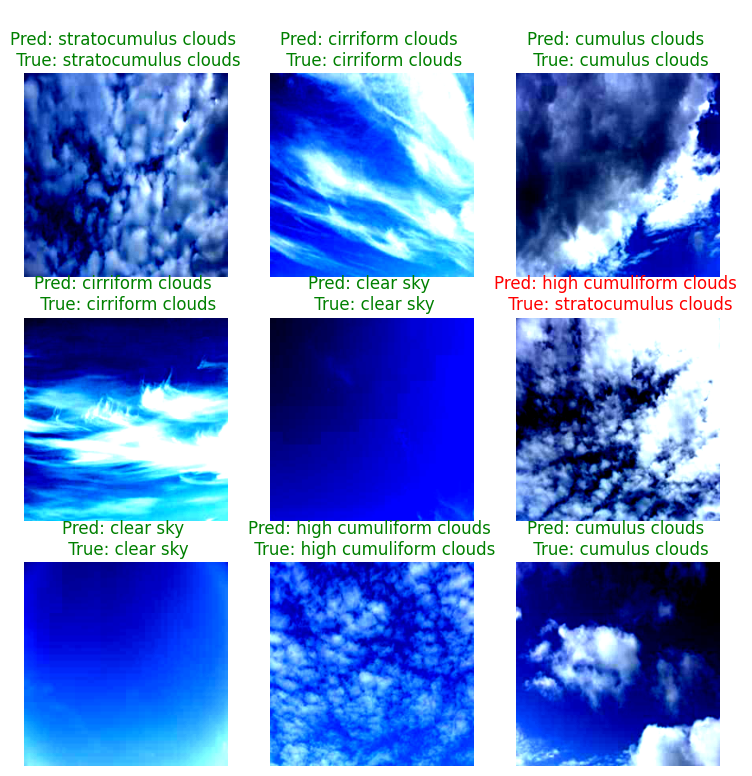

In [18]:
# Visualizing predictions
plt.figure(figsize=(9, 9))

nrows = 3
ncols = 3

random_index = random.randint(0, len(test_data) - 9)


for i, sample in enumerate(test_samples[random_index : random_index + 9]):
    plt.subplot(nrows, ncols, i + 1)

    plt.imshow(sample.permute(1, 2, 0), cmap='grey')

    pred_label = class_names[pred_classes[i + random_index]]

    true_label = class_names[test_labels[i + random_index]]

    title_text = f'\nPred: {pred_label} \n True: {true_label}'

    plt.title(title_text, c='g' if pred_label == true_label else 'r')
    plt.axis(False)

In [19]:
# Imprimindo relatório de classificação
print(classification_report(test_labels, pred_classes))

              precision    recall  f1-score   support

           0       0.89      0.86      0.87        77
           1       0.97      0.98      0.98        64
           2       0.78      0.64      0.70        11
           3       0.87      0.93      0.90       120
           4       0.91      0.83      0.87       103
           5       0.88      0.95      0.92        40
           6       0.81      0.85      0.83        71

    accuracy                           0.89       486
   macro avg       0.87      0.86      0.87       486
weighted avg       0.89      0.89      0.89       486



### Modelo com Data Augmentation


In [20]:
# Criando pipeline de data augmentation
da_data_transforms = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(45),
        transforms.RandomAutocontrast(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

# Importando dados de treino dos arquivos
da_train_data = ImageFolder(
    root='../datasets/clouds/clouds_train',
    transform=da_data_transforms,
)

# Importando dados de treino dos arquivos
da_test_data = ImageFolder(
    root='../datasets/clouds/clouds_test',
    transform=da_data_transforms,
)

In [21]:
# Criando DataLoader de treino
da_train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=32,
    shuffle=True,
)

# Criando DataLoader de teste
da_test_dataloader = DataLoader(
    dataset=train_data,
    batch_size=32,
    shuffle=True,
)

In [22]:
# Instanciando modelo
da_model = ConvNNet(
    input_channels=3,
    num_classes=len(class_to_idx),
).to(device)

In [23]:
# Função de perda
da_loss_fn = nn.CrossEntropyLoss()

# Otimizador
da_optimizer = torch.optim.Adam(
    params=da_model.parameters(),
    lr=1e-4,
)

In [24]:
# Definindo seed
torch.manual_seed(42)

# Definindo número de épocas
epochs = 75

# Definindo numero de iterações para print
print_every = epochs // 10

# Loop de treinamento
for epoch in tqdm(range(epochs)):
    if (epoch + 1) % print_every == 0 or epoch == 0:
        print(
            f'Epoch: {epoch + 1}',
            '-' * 90,
            sep='\n',
            end='\n',
        )

    # Train step
    train_step(
        estimator=da_model,
        dataloader=train_dataloader,
        loss_fn=da_loss_fn,
        optimizer=da_optimizer,
        device=device,
        epoch=epoch,
        print_every=print_every,
    )

    # Test step
    test_step(
        estimator=da_model,
        loss_fn=da_loss_fn,
        dataloader=test_dataloader,
        device=device,
        epoch=epoch,
        print_every=print_every,
    )

  0%|          | 0/75 [00:00<?, ?it/s]

Epoch: 1
------------------------------------------------------------------------------------------
Train loss: 1.698 | Train accuracy: 33.03%
Test loss:  2.033 | Test accuracy:  18.03%

Epoch: 7
------------------------------------------------------------------------------------------
Train loss: 1.059 | Train accuracy: 63.99%
Test loss:  0.971 | Test accuracy:  66.08%

Epoch: 14
------------------------------------------------------------------------------------------
Train loss: 0.877 | Train accuracy: 72.16%
Test loss:  0.768 | Test accuracy:  72.92%

Epoch: 21
------------------------------------------------------------------------------------------
Train loss: 0.721 | Train accuracy: 79.04%
Test loss:  0.578 | Test accuracy:  81.77%

Epoch: 28
------------------------------------------------------------------------------------------
Train loss: 0.668 | Train accuracy: 77.37%
Test loss:  0.525 | Test accuracy:  82.49%

Epoch: 35
----------------------------------------------------

#### Fazendo previsões


In [25]:
# Creating samples and labels lists
test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=len(test_data)):
    test_samples.append(sample)
    test_labels.append(label)

In [26]:
# Making predictions
pred_probs = make_predictions(estimator=da_model, data=test_samples, device=device)

pred_classes = pred_probs.argmax(dim=1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.79929787..1.5942485].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.073294..2.1519828].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6622999..1.4896734].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3130406..2.2216995].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.59380084..1.7511113].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.67942464..1.8382572].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5595

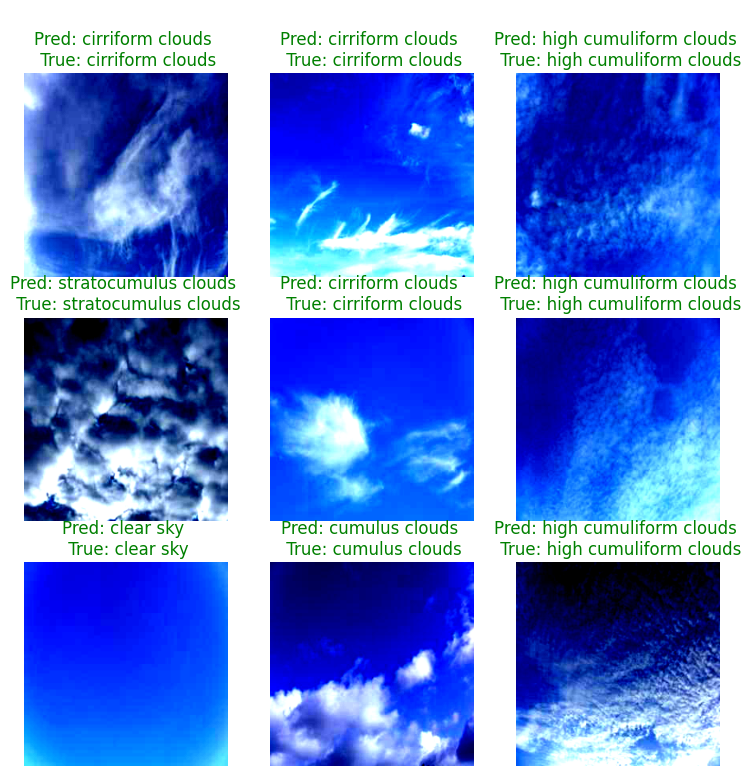

In [27]:
# Visualizing predictions
plt.figure(figsize=(9, 9))

nrows = 3
ncols = 3

random_index = random.randint(0, len(test_data) - 9)


for i, sample in enumerate(test_samples[random_index : random_index + 9]):
    plt.subplot(nrows, ncols, i + 1)

    plt.imshow(sample.permute(1, 2, 0), cmap='grey')

    pred_label = class_names[pred_classes[i + random_index]]

    true_label = class_names[test_labels[i + random_index]]

    title_text = f'\nPred: {pred_label} \n True: {true_label}'

    plt.title(title_text, c='g' if pred_label == true_label else 'r')
    plt.axis(False)

In [28]:
# Imprimindo relatório de classificação
print(classification_report(test_labels, pred_classes))

              precision    recall  f1-score   support

           0       0.90      0.79      0.84        77
           1       0.97      0.98      0.98        64
           2       1.00      0.73      0.84        11
           3       0.90      0.87      0.88       120
           4       0.89      0.83      0.86       103
           5       0.76      0.95      0.84        40
           6       0.74      0.87      0.80        71

    accuracy                           0.87       486
   macro avg       0.88      0.86      0.86       486
weighted avg       0.87      0.87      0.87       486



### Modelo com Transfer Learning


In [38]:
# Criando transformadores de imagens
tl_data_transforms = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

# Criando datasets a partir de arquivos
tl_train_data = ImageFolder(
    '../datasets/clouds/clouds_train',
    transform=data_transforms,
)
tl_test_data = ImageFolder(
    '../datasets/clouds/clouds_test',
    transform=data_transforms,
)

# Criando dataloaders de treino e teste
tl_train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
)
tl_test_loader = DataLoader(
    test_data,
    batch_size=32,
    shuffle=False,
)

In [39]:
tl_model = models.resnet18(weights='IMAGENET1K_V1').to(device)

for param in tl_model.parameters():
    param.requires_grad = False

for param in tl_model.layer4.parameters():
    param.requires_grad = True

tl_model.fc = nn.Linear(tl_model.fc.in_features, len(class_names))

In [40]:
tl_loss_fn = nn.CrossEntropyLoss()

tl_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, tl_model.parameters()),
    lr=1e-4,
)

In [41]:
# Definindo seed
torch.manual_seed(42)

# Definindo número de épocas
epochs = 20

# Definindo numero de iterações para print
print_every = epochs // 10

# Loop de treinamento
for epoch in tqdm(range(epochs)):
    if (epoch + 1) % print_every == 0 or epoch == 0:
        print(
            f'Epoch: {epoch + 1}',
            '-' * 90,
            sep='\n',
            end='\n',
        )

    # Train step
    train_step(
        estimator=tl_model,
        dataloader=tl_train_loader,
        loss_fn=tl_loss_fn,
        optimizer=tl_optimizer,
        device=device,
        epoch=epoch,
        print_every=print_every,
    )

    # Test step
    test_step(
        estimator=tl_model,
        loss_fn=tl_loss_fn,
        dataloader=tl_test_loader,
        device=device,
        epoch=epoch,
        print_every=print_every,
    )

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1
------------------------------------------------------------------------------------------
Train loss: 1.052 | Train accuracy: 66.52%
Test loss:  0.600 | Test accuracy:  84.70%

Epoch: 2
------------------------------------------------------------------------------------------
Train loss: 0.235 | Train accuracy: 96.15%
Test loss:  0.291 | Test accuracy:  90.69%

Epoch: 4
------------------------------------------------------------------------------------------
Train loss: 0.048 | Train accuracy: 100.00%
Test loss:  0.217 | Test accuracy:  92.32%

Epoch: 6
------------------------------------------------------------------------------------------
Train loss: 0.024 | Train accuracy: 100.00%
Test loss:  0.205 | Test accuracy:  92.51%

Epoch: 8
------------------------------------------------------------------------------------------
Train loss: 0.021 | Train accuracy: 100.00%
Test loss:  0.202 | Test accuracy:  92.90%

Epoch: 10
----------------------------------------------------

#### Fazendo previsões


In [42]:
# Creating samples and labels lists
test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=len(test_data)):
    test_samples.append(sample)
    test_labels.append(label)

In [43]:
# Making predictions
pred_probs = make_predictions(estimator=da_model, data=test_samples, device=device)

pred_classes = pred_probs.argmax(dim=1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.38830382..2.1461596].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.59380084..1.7511113].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1760426..2.2391288].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7136741..1.9776908].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6109256..1.541961].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.073294..1.5

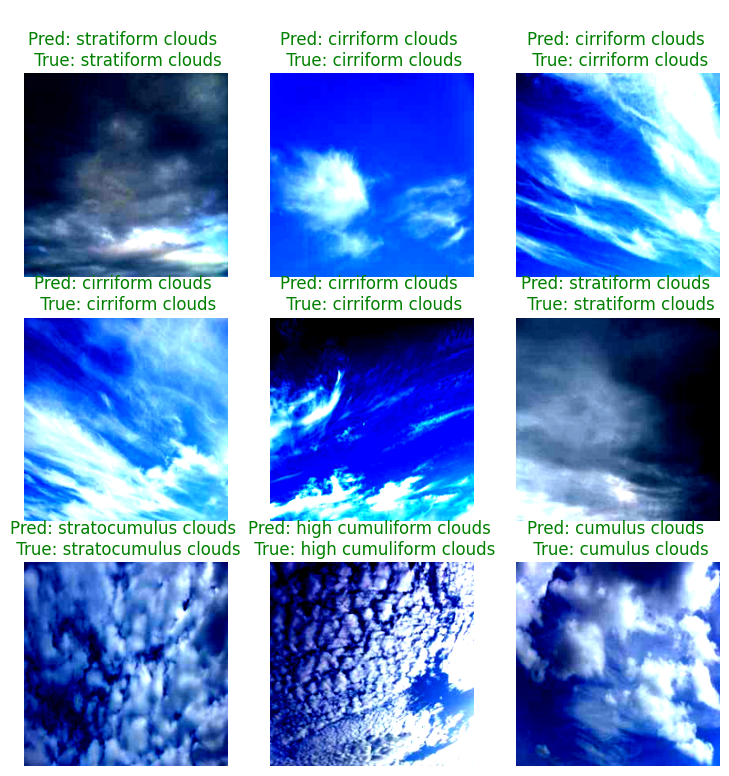

In [46]:
# Visualizing predictions
plt.figure(figsize=(9, 9))

nrows = 3
ncols = 3

random_index = random.randint(0, len(test_data) - 9)


for i, sample in enumerate(test_samples[random_index : random_index + 9]):
    plt.subplot(nrows, ncols, i + 1)

    plt.imshow(sample.permute(1, 2, 0), cmap='grey')

    pred_label = class_names[pred_classes[i + random_index]]

    true_label = class_names[test_labels[i + random_index]]

    title_text = f'\nPred: {pred_label} \n True: {true_label}'

    plt.title(title_text, c='g' if pred_label == true_label else 'r')
    plt.axis(False)

In [45]:
# Imprimindo relatório de classificação
print(classification_report(test_labels, pred_classes))

              precision    recall  f1-score   support

           0       0.90      0.79      0.84        77
           1       0.97      0.98      0.98        64
           2       1.00      0.73      0.84        11
           3       0.90      0.87      0.88       120
           4       0.89      0.83      0.86       103
           5       0.76      0.95      0.84        40
           6       0.74      0.87      0.80        71

    accuracy                           0.87       486
   macro avg       0.88      0.86      0.86       486
weighted avg       0.87      0.87      0.87       486

